# Housing Price Prediction

**Author:** Nijat Aghayev

### Description
This project predicts house prices using features such as area, number of bedrooms, furnishing status, access to the main road and other housing-related attributes. The dataset is not very large, but it is still useful for practice because the features are correlated with each other and the target variable, `price`, is right-skewed.

The main goal is to clean the data, understand the important patterns, prepare the features properly and compare several regression models.

Dataset (Kaggle): https://www.kaggle.com/datasets/yasserh/housing-prices-dataset

### Steps
In this project, I build a supervised regression model and compare four algorithms: **Linear Regression, Ridge, Lasso and Random Forest**. The workflow follows these steps:

1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Data Preprocessing
5. Model Training and Evaluation


In [1]:
# Importing libraries
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42          # fixed seed so results are reproducible
sns.set_theme(style="whitegrid")

# Loading the data


In [2]:
house_data = pd.read_csv("../data/Housing.csv")
house_data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
house_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


# 1. Data cleaning
First we check for missing (NaN) values, then the data types.


### 1.1 Missing values


In [4]:
print("Number of rows :", len(house_data))
print("Missing values :", house_data.isnull().sum().sum())

Number of rows : 545
Missing values : 0


Every column has as many non-null entries as there are rows, so there are **no missing values**.


### 1.2 Data types


In [5]:
numeric_cols = house_data.select_dtypes(include="number").columns.tolist()
categorical_cols = house_data.select_dtypes(exclude="number").columns.tolist()
print("Numerical columns :", numeric_cols)
print("Categorical columns:", categorical_cols)

Numerical columns : ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


There are 6 numerical columns (`price`, `area`, `bedrooms`, `bathrooms`, `stories`, `parking`) and 7 categorical columns. `price` is the value we want to predict.


# 2. EDA (Exploratory Data Analysis)

Here we explore the data from several angles: the summary statistics, the distribution of the target, the distribution of the features, how each feature relates to price, and the correlations between features.


In [6]:
house_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### 2.1 Target distribution


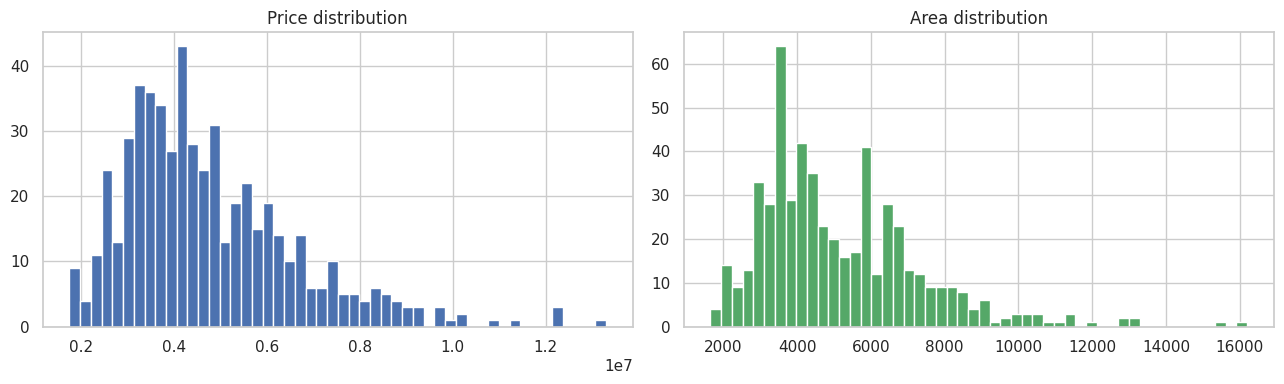

Skewness of price: 1.21
Skewness of area : 1.32


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
house_data["price"].hist(bins=50, ax=ax[0], color="#4C72B0")
ax[0].set_title("Price distribution")
house_data["area"].hist(bins=50, ax=ax[1], color="#55A868")
ax[1].set_title("Area distribution")
plt.tight_layout(); plt.show()
print("Skewness of price:", round(house_data["price"].skew(), 2))
print("Skewness of area :", round(house_data["area"].skew(), 2))

**Insight:** Both `price` and `area` are **right-skewed**. This means that most houses are in a lower or middle price range, while a smaller number of very expensive or very large houses create a long tail. Because of this, I apply a **log transform** to price later in the project. Areas above around 10,500 also look unusually large compared with the rest of the data.


### 2.2 Distribution of the discrete features


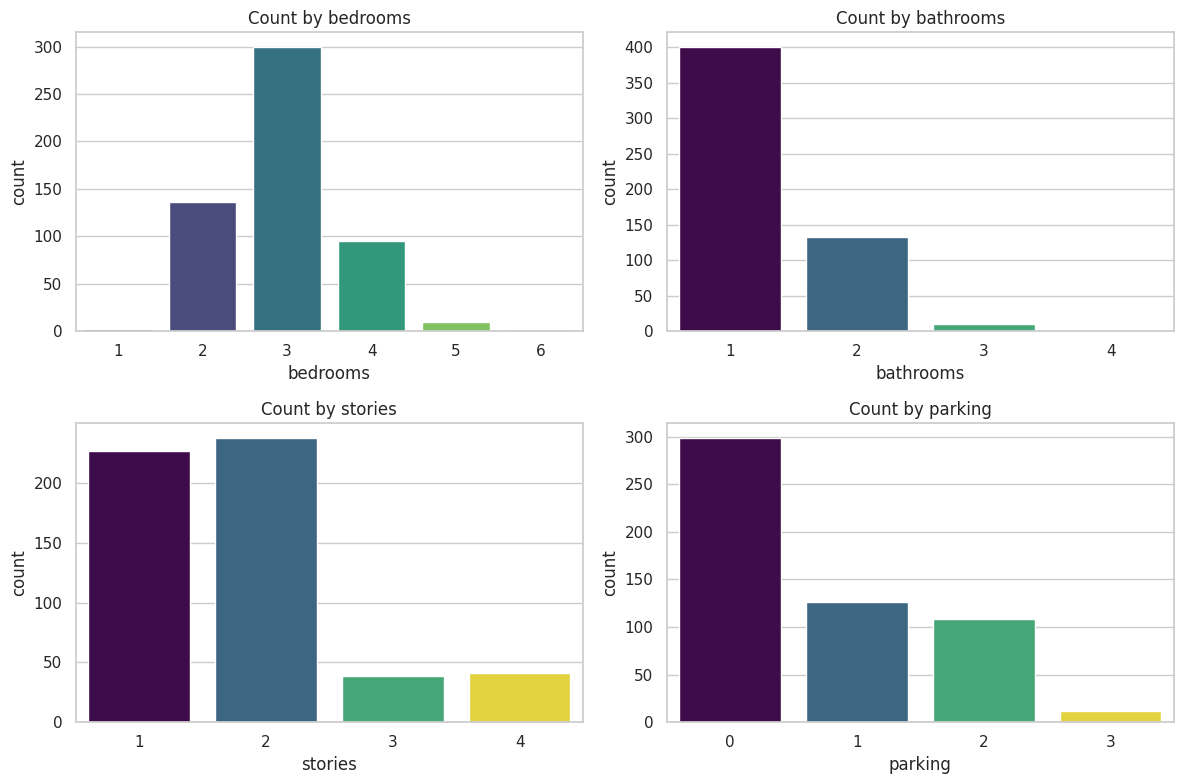

In [8]:
features = ["bedrooms", "bathrooms", "stories", "parking"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for f, ax in zip(features, axes.ravel()):
    sns.countplot(data=house_data, x=f, hue=f, palette="viridis", legend=False, ax=ax)
    ax.set_title(f"Count by {f}")
plt.tight_layout(); plt.show()

**Insight:** most houses have 2-3 bedrooms, 1 bathroom, 1-2 stories and 0-1 parking spots. Very large counts are rare, which is worth remembering when interpreting the model.


### 2.3 How price relates to the main features


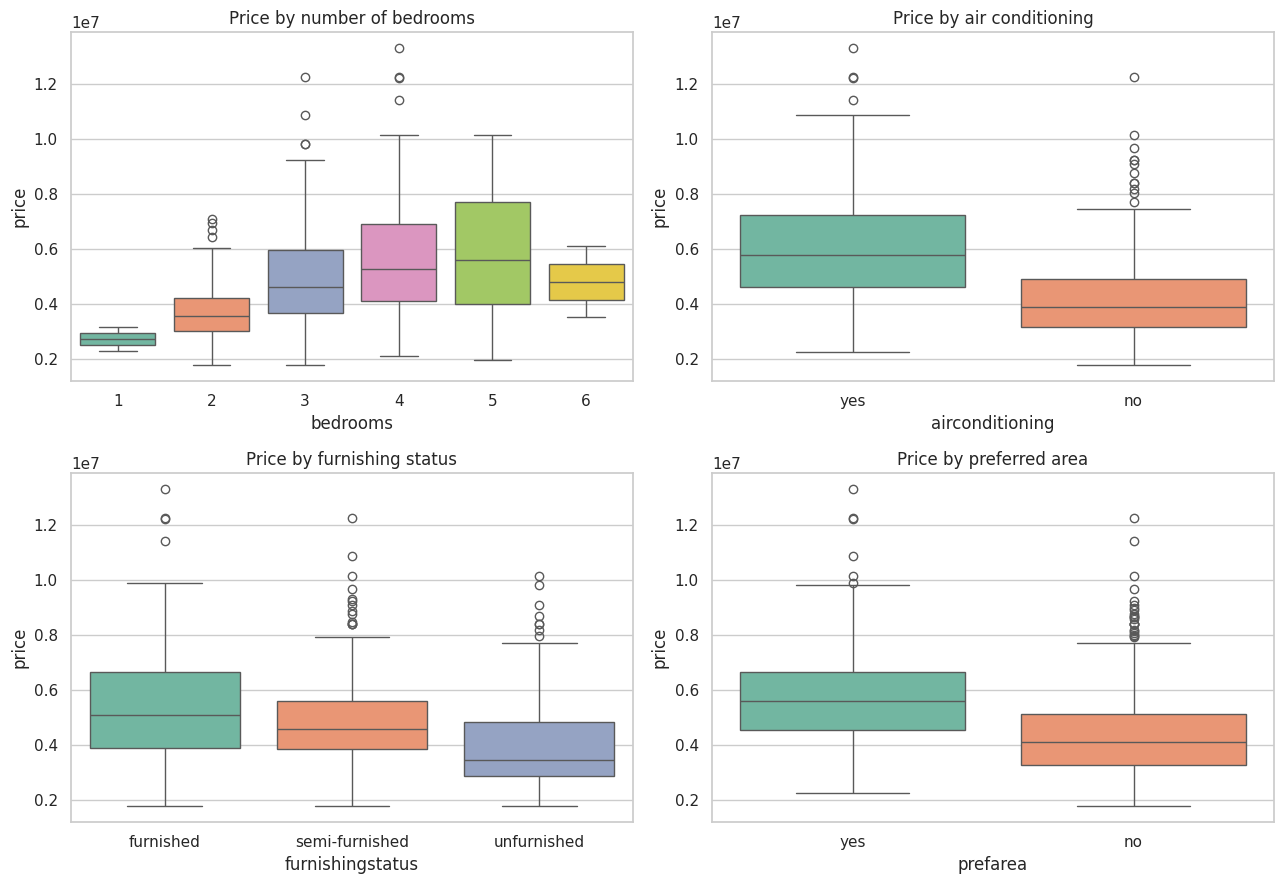

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.boxplot(data=house_data, x="bedrooms", y="price", hue="bedrooms",
            palette="Set2", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Price by number of bedrooms")
sns.boxplot(data=house_data, x="airconditioning", y="price", hue="airconditioning",
            palette="Set2", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Price by air conditioning")
sns.boxplot(data=house_data, x="furnishingstatus", y="price", hue="furnishingstatus",
            palette="Set2", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Price by furnishing status")
sns.boxplot(data=house_data, x="prefarea", y="price", hue="prefarea",
            palette="Set2", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Price by preferred area")
plt.tight_layout(); plt.show()

**Insight:** Houses with air conditioning, houses in a preferred area and furnished houses usually have higher prices. Price also tends to increase as the number of bedrooms increases. These features seem to contain useful information, so they should be encoded carefully before modelling.


### 2.4 Area vs price


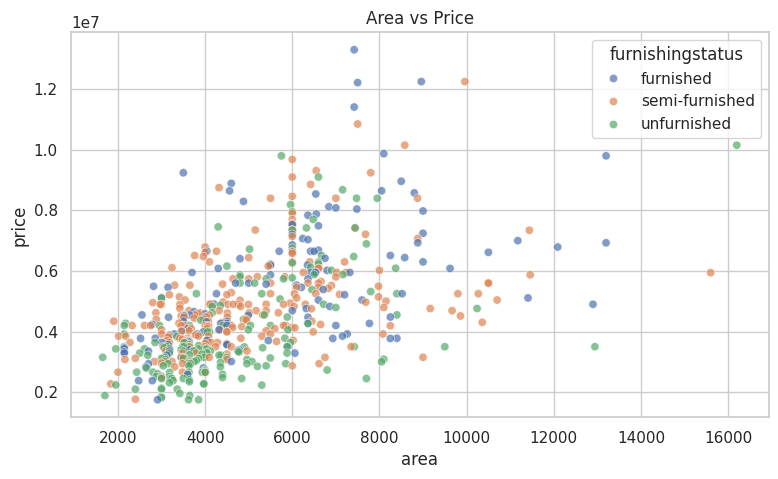

In [10]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=house_data, x="area", y="price", hue="furnishingstatus", alpha=0.7)
plt.title("Area vs Price")
plt.show()

**Insight:** `area` has a clear positive relationship with `price`. In general, larger houses tend to be more expensive, so area looks like one of the strongest predictors in the dataset.


### 2.5 Correlations


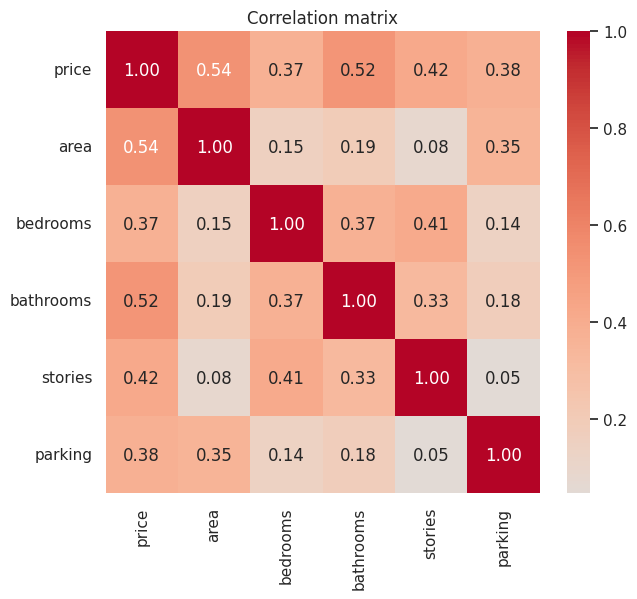

In [11]:
corr = house_data[numeric_cols].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation matrix")
plt.show()

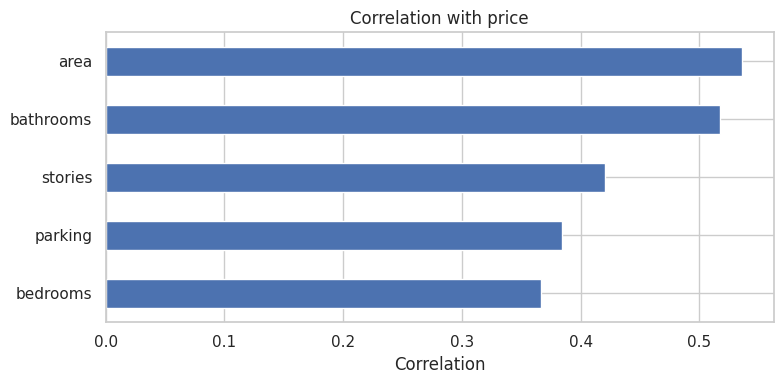

In [12]:
# Correlation of each numerical feature with price
corr_with_price = corr["price"].drop("price").sort_values()
plt.figure(figsize=(8, 4))
corr_with_price.plot(kind="barh", color="#4C72B0")
plt.title("Correlation with price")
plt.xlabel("Correlation")
plt.tight_layout(); plt.show()

**Insight:** `area` has the strongest correlation with `price`, followed by `bathrooms` and `stories`. At the same time, some of these features are also correlated with each other. This is the multicollinearity problem mentioned earlier. To handle this more safely, I also test **Ridge** and **Lasso**, which are regularized linear models.


### 2.6 Relationships among the numerical features


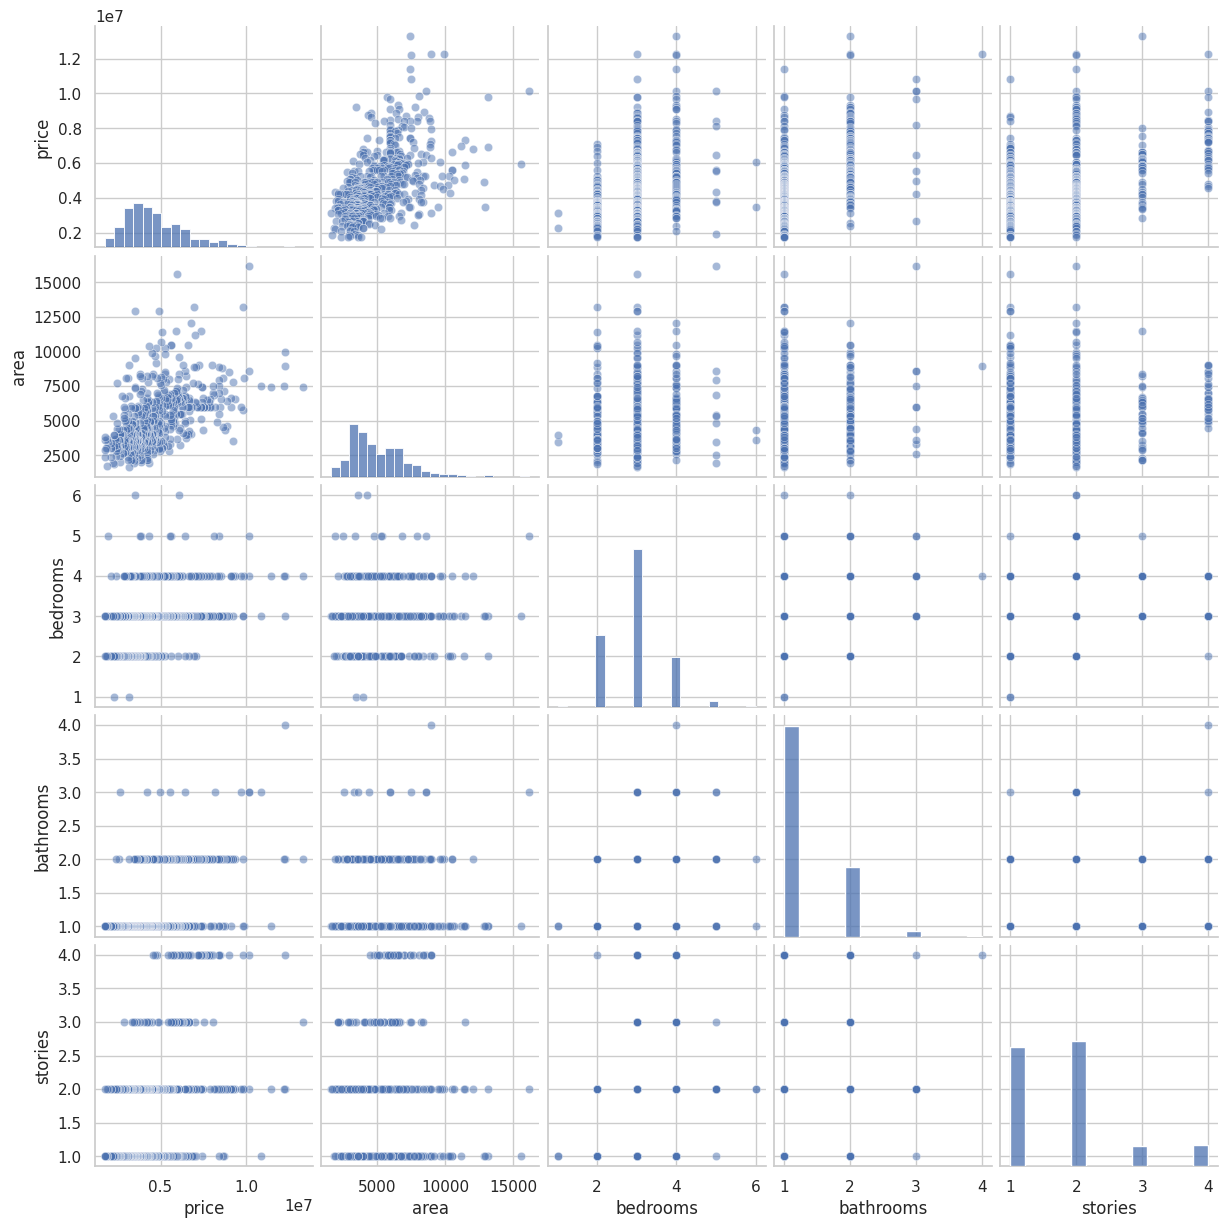

In [13]:
sns.pairplot(house_data[["price", "area", "bedrooms", "bathrooms", "stories"]],
             diag_kind="hist", plot_kws={"alpha": 0.5})
plt.show()

**Insight:** The pairplot supports what we saw earlier. Price generally increases with the main structural features, and some features move together. This again shows that multicollinearity exists in the dataset.


### 2.7 Average price by furnishing status


In [14]:
house_data.groupby("furnishingstatus")["price"].mean().sort_values(ascending=False)

furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64

**Insight:** The average price increases from unfurnished to semi-furnished to furnished homes. This suggests an ordinal relationship, so I encode `furnishingstatus` as 0/1/2. One-hot encoding could also be tested as an alternative, but ordinal encoding is reasonable here because the categories have a meaningful order.


# 3. Outlier handling

Very large **area** values look unusual compared with the rest of the dataset, so I remove only those extreme area outliers. I do **not** remove rows only because the *price* is high. Price is the target variable, and removing expensive houses could make the model biased toward cheaper houses. For that reason, I only remove outliers from the feature `area` and report how many rows are removed.


In [15]:
before = len(house_data)
house_clean = house_data[house_data["area"] <= 10500].reset_index(drop=True)
print("Rows removed (area > 10500):", before - len(house_clean))
print("Shape after cleaning       :", house_clean.shape)

Rows removed (area > 10500): 12
Shape after cleaning       : (533, 13)


# 4. Feature engineering


In [16]:
df = house_clean.copy()

# 4.1 Encode binary yes/no columns -> 1/0
binary_cols = ["mainroad", "guestroom", "basement",
               "hotwaterheating", "airconditioning", "prefarea"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

# 4.2 furnishingstatus has a natural order -> encode as 0/1/2
df["furnishingstatus"] = df["furnishingstatus"].map(
    {"unfurnished": 0, "semi-furnished": 1, "furnished": 2})

# 4.3 New feature: total rooms (we keep the original columns)
df["total_rooms"] = df["bedrooms"] + df["bathrooms"] + df["stories"]

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2,9
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2,12
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,7
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2,8
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2,7


**What we did:** Binary `yes/no` columns were converted to `1/0`. The `furnishingstatus` column was encoded as `0/1/2` because it has an ordered structure. I also added a new feature called `total_rooms` while keeping the original room-related columns.


# 5. Data preprocessing

There are two main preparation steps in this part.

**Log transform of the target.** Since `price` is right-skewed, I train the models on `log(price)` instead of the original price values. The log transform reduces the effect of very large prices and makes the target distribution easier for the models to learn. When reporting the final error, I convert the predictions back to real prices using the inverse transformation, `expm1`.

**Feature scaling.** Ridge and Lasso are affected by the scale of the features. For example, `area` can be in the thousands, while `bedrooms` is usually a small number. To make the features comparable, I standardize them using `StandardScaler`. I use a `Pipeline` so that scaling is learned only from the training data and does not leak information from the test set.


In [17]:
from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)
y = df["price"]
y_log = np.log1p(y)          # log-transformed target

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE)

# keep the real (non-log) test prices for reporting the error in real money
y_test = np.expm1(y_test_log)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (426, 13) | Test size: (107, 13)


# 6. Model training and evaluation

I compare four regression models:

- **Linear Regression:** a simple baseline model.
- **Ridge:** a linear model with L2 regularization, useful when features are correlated.
- **Lasso:** a linear model with L1 regularization, which can reduce the effect of less useful features.
- **Random Forest:** a tree-based model that can capture non-linear relationships.

**Metrics:** I use R², MAE and RMSE to evaluate the models. R² shows how much variance the model explains, while MAE and RMSE show the prediction error.

**Cross-validation:** I use 5-fold cross-validation with `shuffle=True`. The dataset is sorted by price, so shuffling is important. Without shuffling, each fold could represent a different price range and the results would be less reliable.


In [18]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge":             make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso":             make_pipeline(StandardScaler(), Lasso(alpha=0.001, max_iter=50000)),
    "Random Forest":     make_pipeline(StandardScaler(), RandomForestRegressor(random_state=RANDOM_STATE)),
}

scores = {}
for name, pipe in models.items():
    cv = cross_val_score(pipe, X_train, y_train_log, cv=kf, scoring="r2")
    scores[name] = cv.mean()
    print(f"{name:18s} -> CV R2: {cv.mean():.3f} (+/- {cv.std():.3f})")

best_name = max(scores, key=scores.get)
print("\nBest model by CV R2:", best_name)

Linear Regression  -> CV R2: 0.664 (+/- 0.047)
Ridge              -> CV R2: 0.664 (+/- 0.047)
Lasso              -> CV R2: 0.664 (+/- 0.046)


Random Forest      -> CV R2: 0.625 (+/- 0.046)

Best model by CV R2: Ridge


**Insight:** The models perform quite similarly, with R² scores around 0.62 to 0.64. Since the dataset is small, Ridge and Lasso do not improve the result much compared with Linear Regression. Still, they are useful because they make the model more stable when correlated features are present. I continue with the best-performing model from this comparison.


### Train and evaluate the best model


In [19]:
best_model = models[best_name]
best_model.fit(X_train, y_train_log)

# predict on the log scale, then convert back to real prices
y_pred = np.expm1(best_model.predict(X_test))

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Final model: {best_name}")
print(f"Test R2  : {r2:.3f}")
print(f"Test MAE : {mae:,.0f}")
print(f"Test RMSE: {rmse:,.0f}")
print(f"Mean price: {y.mean():,.0f}  ->  MAE is about {mae / y.mean() * 100:.0f}% of the mean price")

Final model: Ridge
Test R2  : 0.623
Test MAE : 926,087
Test RMSE: 1,340,521
Mean price: 4,726,995  ->  MAE is about 20% of the mean price


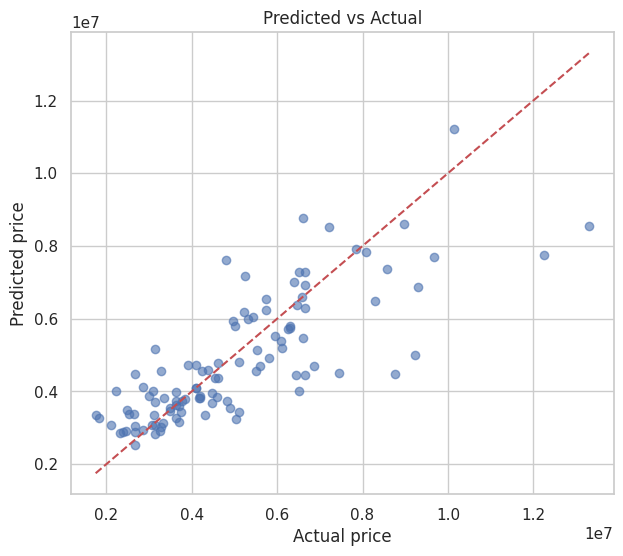

In [20]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="#4C72B0")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual price"); plt.ylabel("Predicted price")
plt.title("Predicted vs Actual")
plt.show()

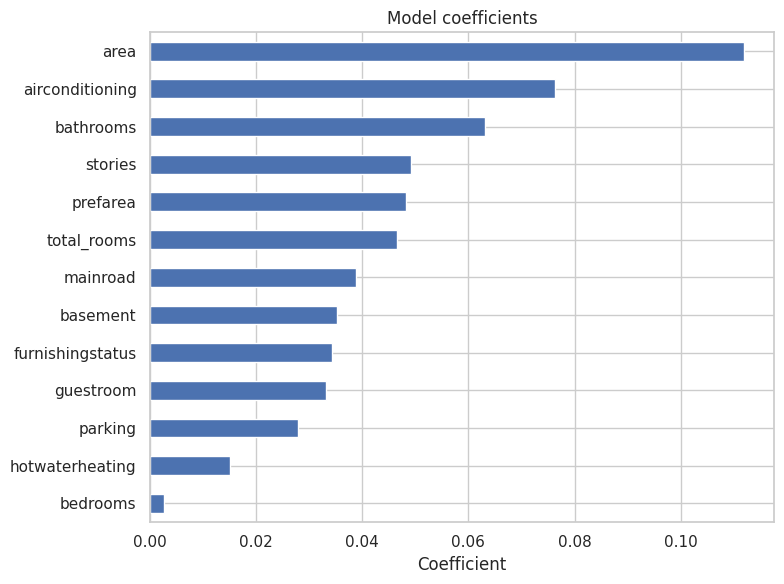

In [21]:
# What drives the prediction? (importances for the tree model, coefficients for linear)
final_estimator = best_model[-1]
if hasattr(final_estimator, "feature_importances_"):
    values, title, xlab = final_estimator.feature_importances_, "Feature importance", "Importance"
else:
    values, title, xlab = final_estimator.coef_, "Model coefficients", "Coefficient"

pd.Series(values, index=X.columns).sort_values().plot(
    kind="barh", figsize=(8, 6), color="#4C72B0")
plt.title(title); plt.xlabel(xlab)
plt.tight_layout(); plt.show()

**Insight:** `area` is the most important feature, which matches the EDA results. In the predicted vs actual plot, many points are reasonably close to the diagonal line, so the model gives acceptable predictions for this dataset.


# 7. Save the model


In [22]:
import joblib
joblib.dump(best_model, "../models/house_price_model.pkl")
print("Model saved to ../models/house_price_model.pkl")

loaded_model = joblib.load("../models/house_price_model.pkl")
print("Reloaded model loads correctly:", loaded_model is not None)

Model saved to ../models/house_price_model.pkl
Reloaded model loads correctly: True


# Conclusion

In this project, I built and compared four regression models for house price prediction. The workflow included data cleaning, EDA, feature engineering, preprocessing and model evaluation. Two important challenges were handled during the process: multicollinearity between features and the right-skewed price distribution. I used Ridge and Lasso to deal with correlated features, and I applied a log transform to make the target easier to model.

The final models reach an R² of around 0.6, and `area` appears to be the most influential feature.

**Why is the score not higher?** The dataset is small, with around 500 rows, and it does not include detailed location information. In real estate, location is usually one of the strongest price drivers. Because this important information is missing, the maximum possible accuracy is limited. With neighbourhood data and more samples, the model could likely perform better.
